In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numdifftools as nd
import model_interface as mi

In [24]:

state = mi.DEFAULT_STATE.copy()
inputs = {"glu_in": 5.0, "fat_in": 2.0, "atp_draw": 1.0}

mi.derivatives(0, state, inputs)


[np.float64(5.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(2.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]

In [25]:
next_state, flux = mi.step_ivp_once(
    state,
    glu_in=5.0,
    fat_in=2.0,
    atp_draw=1.0,
    dt=0.05
)

next_state, flux


(array([2.48793934e-01, 1.12896863e-03, 7.07029671e-05, 4.13737500e-06,
        4.03666850e-07, 4.74161182e-08, 7.01729234e-04, 3.59769797e-04,
        8.56422984e-02, 1.21510873e-02, 1.12675971e-03, 8.80893207e-09]),
 0.027680682457832215)

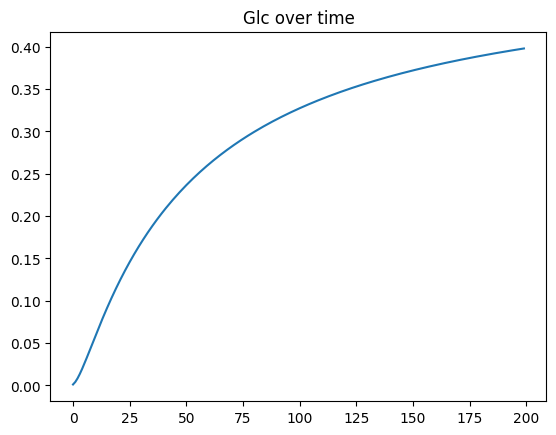

In [26]:
state = mi.DEFAULT_STATE.copy()
history = []

for _ in range(200):
    state, flux = mi.step_ivp_once(state, 5.0, 2.0, 1.0)
    history.append((state.copy(), flux))

len(history)


Glc_trace = [h[0][mi.STATE_NAMES.index("Glc")] for h in history]

plt.plot(Glc_trace)
plt.title("Glc over time")
plt.show()


In [27]:
fluxes = mi.compute_all_fluxes(state, inputs)
fluxes


{'GLUT4': 0.8948904873252964,
 'Glycolysis': 0.3101716641740786,
 'PDH': 0.30010779429375645,
 'Citrate_prod': 1.0856822338513896,
 'ACL_ACC': 0.10944876516318726,
 'CD36': 0.9904734694272421,
 'CPT1': 0.8899185792717639,
 'BetaOx': 0.8898870043552827,
 'FAS': 0.060024419053223685,
 'Net_Cit': 0.9762334686882024}

### Stability check of ODE system

In [28]:

state = np.array([1.0]*len(mi.STATE_NAMES))
inputs = {"glu_in":5,"fat_in":2,"atp_draw":1}

def f(x):
    return np.array(mi.derivatives(0, x, inputs))

J = nd.Jacobian(f)(state)
np.linalg.eigvals(J)


array([-0.78371728+0.11273014j, -0.78371728-0.11273014j,
       -0.17056295+0.16229037j, -0.17056295-0.16229037j,
       -0.13793492+0.j        , -0.00846293+0.j        ,
       -0.02399833+0.j        , -0.07884282+0.j        ,
       -0.4295375 +0.j        , -0.44444444+0.j        ,
       -0.13888889+0.j        , -0.08264463+0.j        ])

In [29]:
dts = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01]

state0 = mi.DEFAULT_STATE.copy()

for dt in dts:
    state = state0.copy()
    try:
        for _ in range(200):   # 200 steps = quick stability probe
            state, flux = mi.step_ivp_once(state, 5, 2, 1, dt=dt)
        print(f"dt={dt}: OK  sum={state.sum():.4f}")
    except Exception as e:
        print(f"dt={dt}: FAIL  {e}")

dt=0.5: OK  sum=656.7694
dt=0.2: OK  sum=262.9952
dt=0.1: OK  sum=131.9568
dt=0.05: OK  sum=66.4574
dt=0.02: OK  sum=27.0340
dt=0.01: OK  sum=13.7117


In [30]:
methods = ["RK45", "RK23", "Radau", "BDF"]
state0 = mi.DEFAULT_STATE.copy()

for m in methods:
    state = state0.copy()
    try:
        for _ in range(200):
            state, flux = mi.step_ivp_once(state, 5, 2, 1, dt=0.05, method=m)
        print(f"{m}: OK  sum={state.sum():.4f}")
    except Exception as e:
        print(f"{m}: FAIL  {e}")

RK45: OK  sum=66.4574
RK23: OK  sum=66.4574
Radau: OK  sum=66.4574
BDF: OK  sum=66.4552


In [31]:

def run_flux(glu_in, fat_in, atp_draw):
    state = mi.DEFAULT_STATE.copy()
    for _ in range(200):
        state, flux = mi.step_ivp_once(state, glu_in, fat_in, atp_draw, dt=0.05)
    return mi.compute_all_fluxes(state, {"glu_in": glu_in, "fat_in": fat_in, "atp_draw": atp_draw})

glu_vals = [0, 2, 5, 10]
fat_vals = [0, 1, 2, 4]

for g in glu_vals:
    for f in fat_vals:
        fluxes = run_flux(g, f, 1.0)
        print(f"glu={g}, fat={f}, PDH={fluxes['PDH']:.3f}, BetaOx={fluxes['BetaOx']:.3f}")

glu=0, fat=0, PDH=0.000, BetaOx=0.000
glu=0, fat=1, PDH=0.000, BetaOx=0.886
glu=0, fat=2, PDH=0.000, BetaOx=0.922
glu=0, fat=4, PDH=0.000, BetaOx=0.926
glu=2, fat=0, PDH=0.454, BetaOx=0.038
glu=2, fat=1, PDH=0.292, BetaOx=0.867
glu=2, fat=2, PDH=0.284, BetaOx=0.897
glu=2, fat=4, PDH=0.282, BetaOx=0.901
glu=5, fat=0, PDH=0.515, BetaOx=0.055
glu=5, fat=1, PDH=0.309, BetaOx=0.862
glu=5, fat=2, PDH=0.300, BetaOx=0.890
glu=5, fat=4, PDH=0.298, BetaOx=0.894
glu=10, fat=0, PDH=0.527, BetaOx=0.063
glu=10, fat=1, PDH=0.313, BetaOx=0.859
glu=10, fat=2, PDH=0.304, BetaOx=0.886
glu=10, fat=4, PDH=0.302, BetaOx=0.890


### Full simulation test

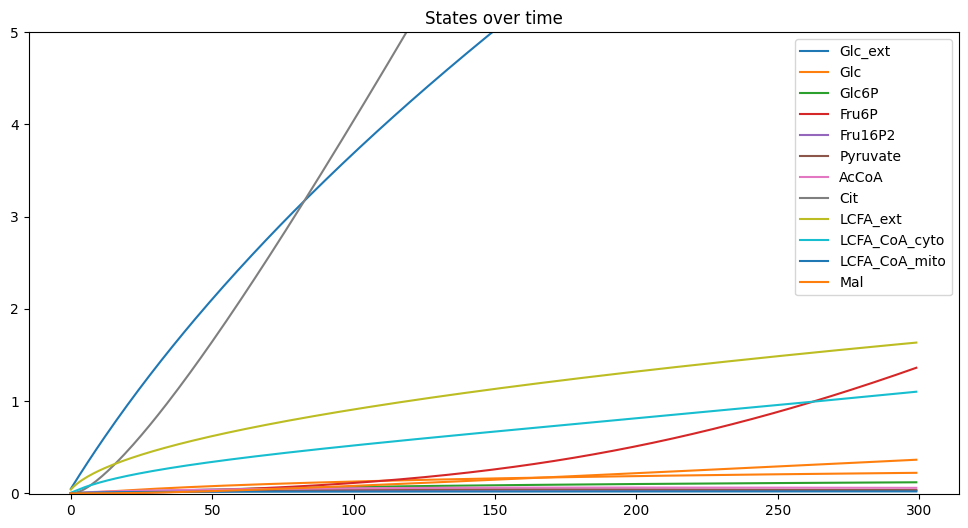

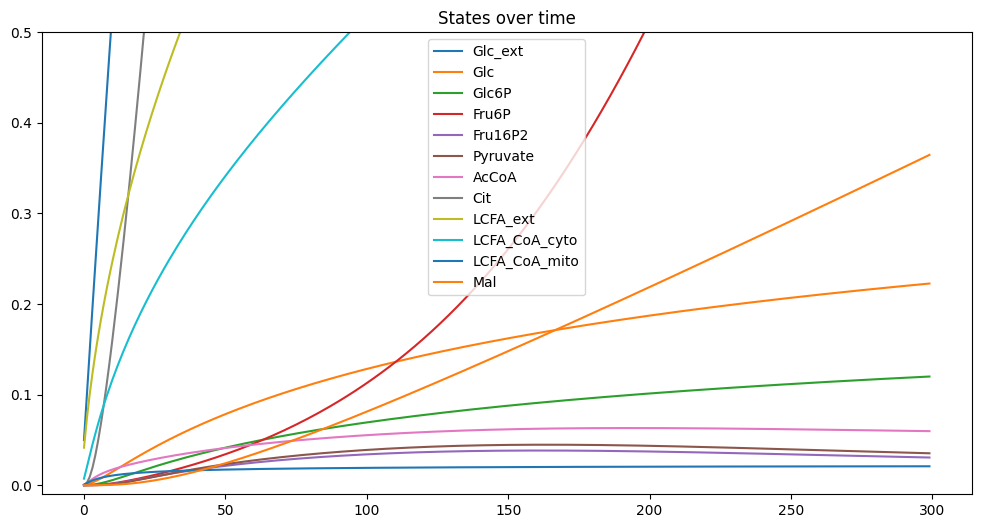

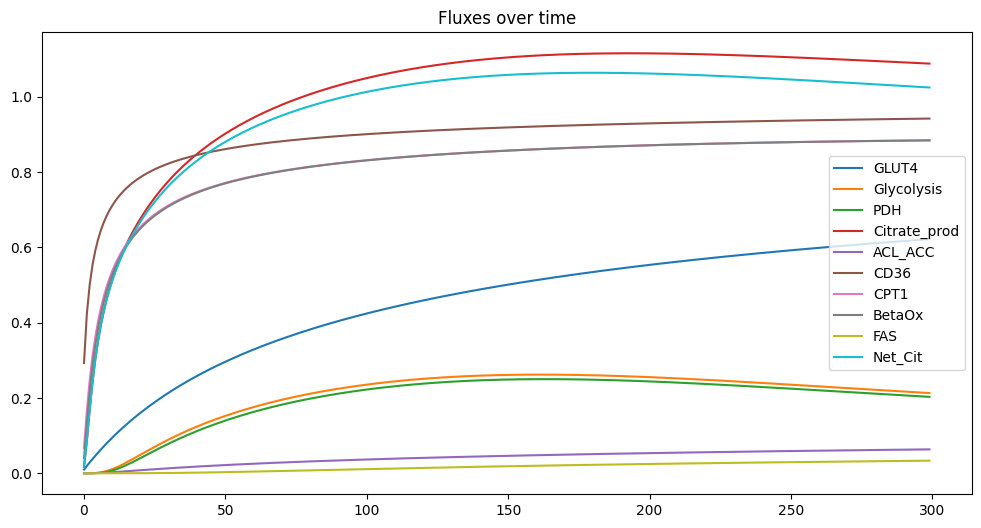

In [5]:

# --- run simulation ---
steps = 300
dt = 0.05

state = mi.DEFAULT_STATE.copy()
inputs = {"glu_in":1, "fat_in":1, "atp_draw":0}

state_hist = []
flux_hist = []

for _ in range(steps):
    state, flux = mi.step_ivp_once(state, **inputs, dt=dt)
    state_hist.append(state.copy())
    flux_hist.append(mi.compute_all_fluxes(state, inputs))

state_hist = np.array(state_hist)

plt.figure(figsize=(12,6))
for i,name in enumerate(mi.STATE_NAMES):
    plt.plot(state_hist[:,i], label=name)
plt.ylim(-0.01, 5.0)
plt.legend()
plt.title("States over time")
plt.show()

plt.figure(figsize=(12,6))
for i,name in enumerate(mi.STATE_NAMES):
    plt.plot(state_hist[:,i], label=name)
plt.ylim(-0.01, 0.5)
plt.legend()
plt.title("States over time")
plt.show()

plt.figure(figsize=(12,6))
for key in flux_hist[0].keys():
    plt.plot([f[key] for f in flux_hist], label=key)
plt.legend()
plt.title("Fluxes over time")
plt.show()


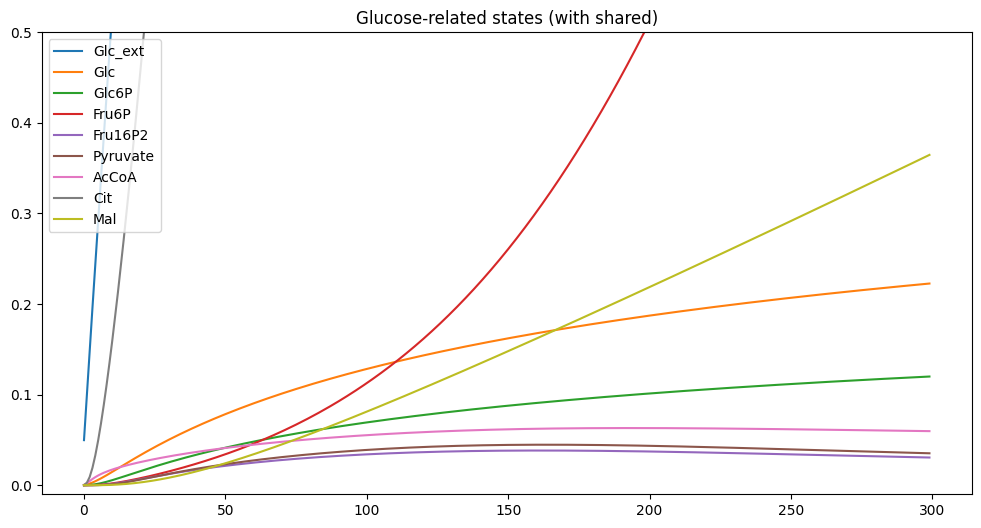

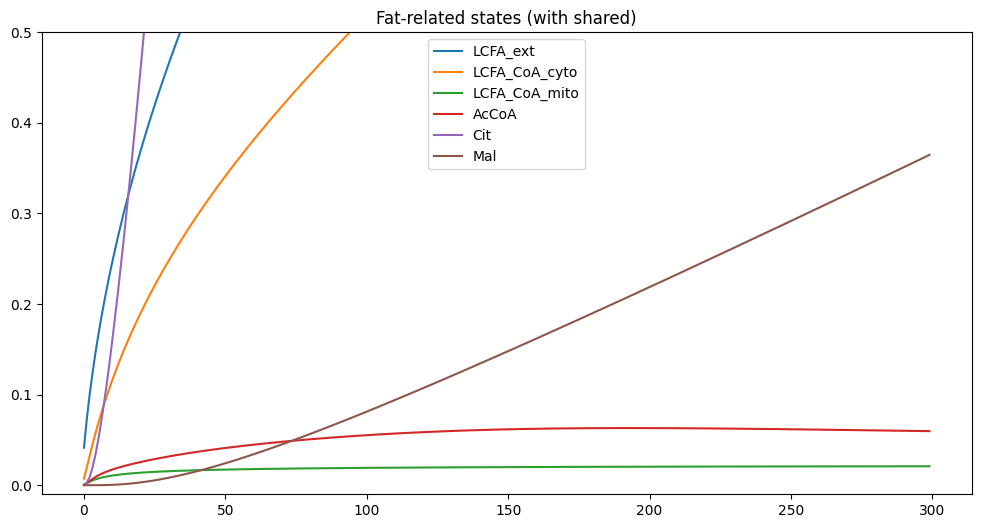

In [6]:
glucose_states = ["Glc_ext","Glc","Glc6P","Fru6P","Fru16P2","Pyruvate"]
fat_states     = ["LCFA_ext","LCFA_CoA_cyto","LCFA_CoA_mito"]
shared_states  = ["AcCoA","Cit","Mal"]


plt.figure(figsize=(12,6))
for name in glucose_states + shared_states:
    idx = mi.STATE_NAMES.index(name)
    plt.plot(state_hist[:, idx], label=name)
plt.ylim(-0.01, 0.5)
plt.legend()
plt.title("Glucose-related states (with shared)")
plt.show()

plt.figure(figsize=(12,6))
for name in fat_states + shared_states:
    idx = mi.STATE_NAMES.index(name)
    plt.plot(state_hist[:, idx], label=name)
plt.ylim(-0.01, 0.5)
plt.legend()
plt.title("Fat-related states (with shared)")
plt.show()

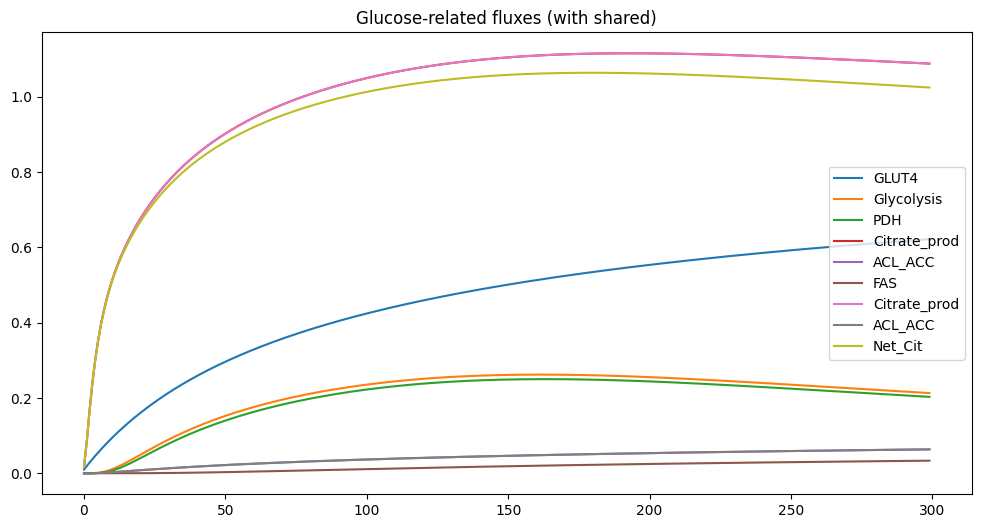

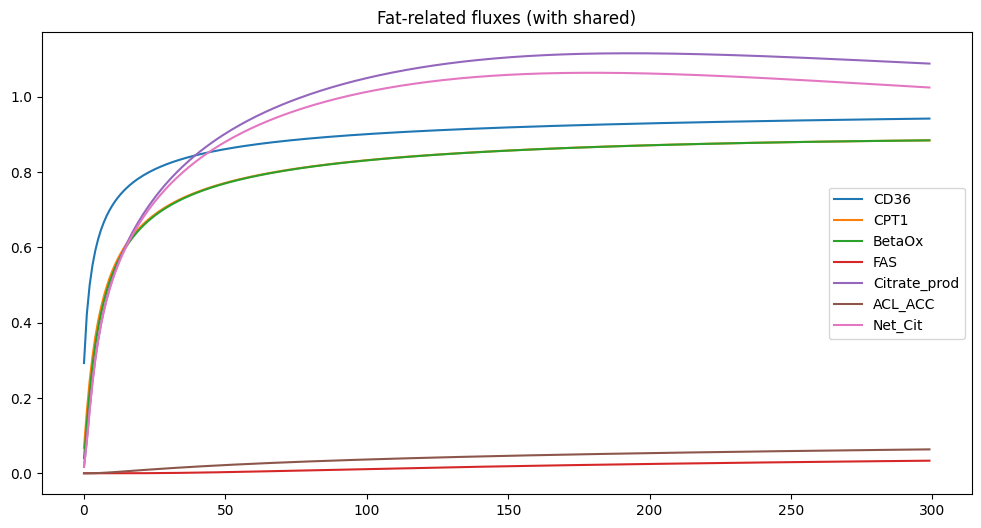

In [7]:
glucose_fluxes = ["GLUT4","Glycolysis","PDH","Citrate_prod","ACL_ACC","FAS"]
fat_fluxes     = ["CD36","CPT1","BetaOx","FAS"]
shared_fluxes  = ["Citrate_prod","ACL_ACC","Net_Cit"]

plt.figure(figsize=(12,6))
for key in glucose_fluxes + shared_fluxes:
    plt.plot([f[key] for f in flux_hist], label=key)
plt.legend()
plt.title("Glucose-related fluxes (with shared)")
plt.show()

plt.figure(figsize=(12,6))
for key in fat_fluxes + shared_fluxes:
    plt.plot([f[key] for f in flux_hist], label=key)
plt.legend()
plt.title("Fat-related fluxes (with shared)")
plt.show()

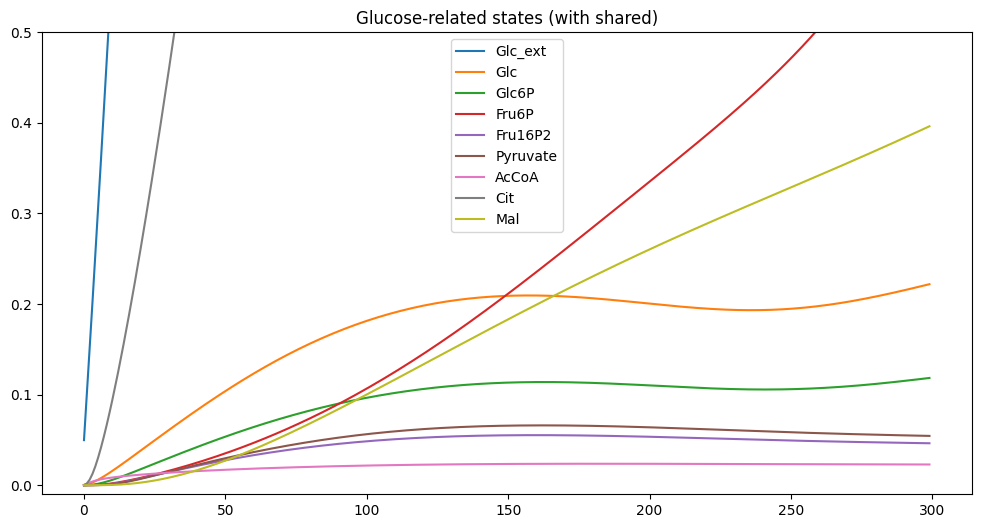

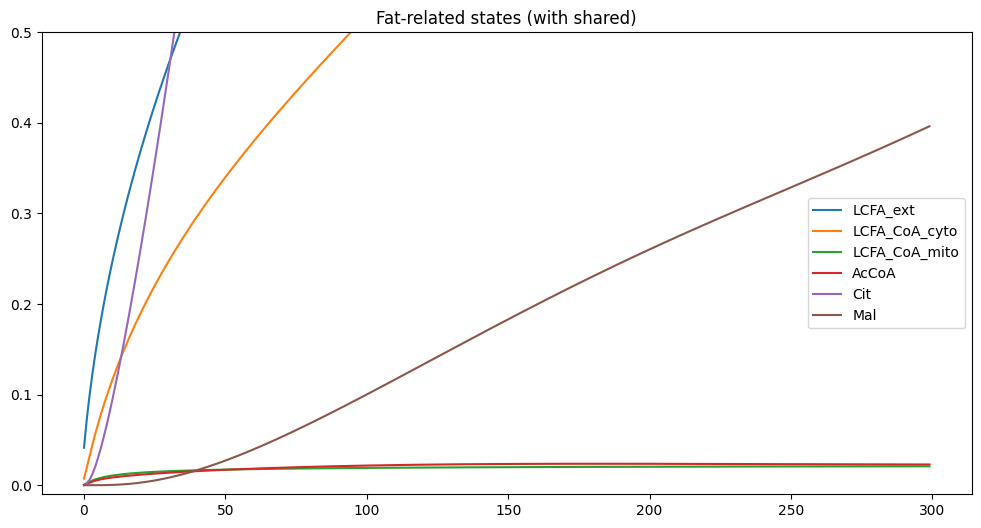

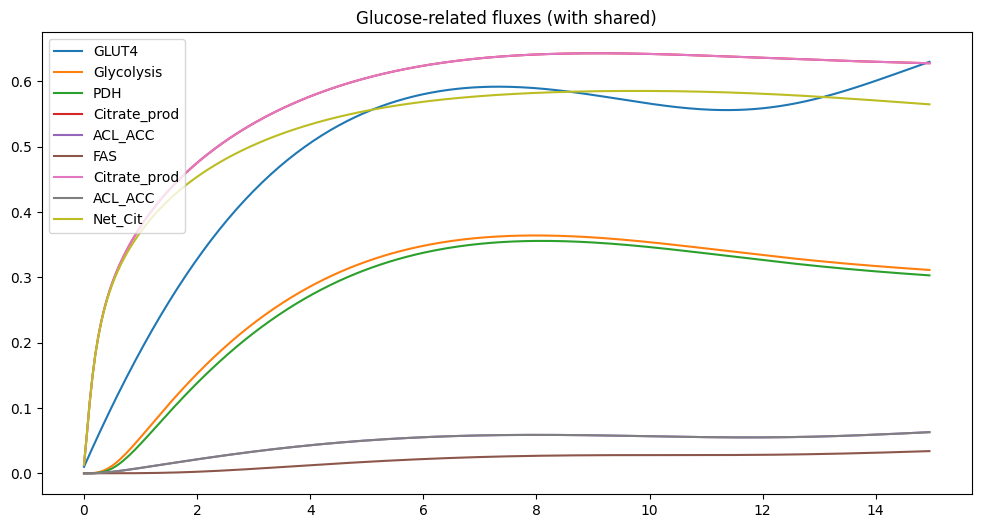

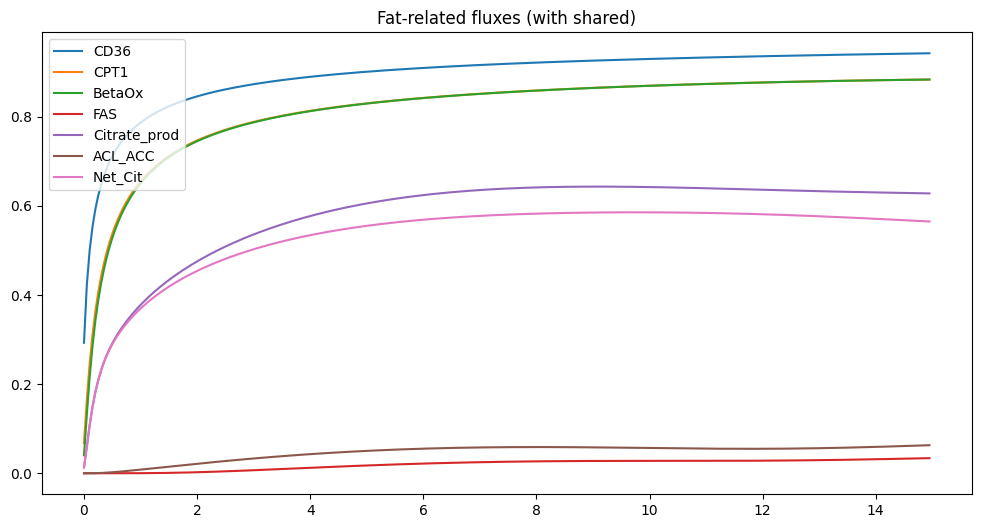

In [11]:
# --- run simulation ---
steps = 300
dt = 0.05

t = np.arange(steps) * dt

def glu_in_func(t):
    return 1.0 + 0.8*np.sin(0.5*t)   # oscillating glucose

def fat_in_func(t):
    return 1.0                      # constant fat

def atp_draw_func(t):
    return 0.5

state = mi.DEFAULT_STATE.copy()

state_hist = []
flux_hist = []

for k in range(steps):
    ti = t[k]
    inputs = {
        "glu_in": glu_in_func(ti),
        "fat_in": fat_in_func(ti),
        "atp_draw": atp_draw_func(ti)
    }

    state, flux = mi.step_ivp_once(state, **inputs, dt=dt)
    state_hist.append(state.copy())
    flux_hist.append(mi.compute_all_fluxes(state, inputs))

state_hist = np.array(state_hist)

glucose_states = ["Glc_ext","Glc","Glc6P","Fru6P","Fru16P2","Pyruvate"]
fat_states     = ["LCFA_ext","LCFA_CoA_cyto","LCFA_CoA_mito"]
shared_states  = ["AcCoA","Cit","Mal"]


plt.figure(figsize=(12,6))
for name in glucose_states + shared_states:
    idx = mi.STATE_NAMES.index(name)
    plt.plot(state_hist[:, idx], label=name)
plt.ylim(-0.01, 0.5)
plt.legend()
plt.title("Glucose-related states (with shared)")
plt.show()

plt.figure(figsize=(12,6))
for name in fat_states + shared_states:
    idx = mi.STATE_NAMES.index(name)
    plt.plot(state_hist[:, idx], label=name)
plt.ylim(-0.01, 0.5)
plt.legend()
plt.title("Fat-related states (with shared)")
plt.show()

glucose_fluxes = ["GLUT4","Glycolysis","PDH","Citrate_prod","ACL_ACC","FAS"]
fat_fluxes     = ["CD36","CPT1","BetaOx","FAS"]
shared_fluxes  = ["Citrate_prod","ACL_ACC","Net_Cit"]

plt.figure(figsize=(12,6))
for key in glucose_fluxes + shared_fluxes:
    plt.plot(t, [f[key] for f in flux_hist], label=key)
plt.legend()
plt.title("Glucose-related fluxes (with shared)")
plt.show()

plt.figure(figsize=(12,6))
for key in fat_fluxes + shared_fluxes:
    plt.plot(t, [f[key] for f in flux_hist], label=key)
plt.legend()
plt.title("Fat-related fluxes (with shared)")
plt.show()